In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 1. LOAD CSV LOCALLY IN CHUNKS, SAMPLING EACH CHUNK
file_name = "flights.csv"   # use the full path if it's not in the same folder
SAMPLE_FRAC = 0.20          # fraction of rows kept from every chunk (~1.16M rows total)

use_cols = [
    'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE',
    'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
    'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME', 'DISTANCE',
    'ARRIVAL_DELAY', 'CANCELLED', 'DIVERTED'
]

chunks = []
for chunk in pd.read_csv(
    file_name,
    usecols=use_cols,
    dtype={'ORIGIN_AIRPORT': str, 'DESTINATION_AIRPORT': str},
    chunksize=500_000
):
    chunks.append(chunk.sample(frac=SAMPLE_FRAC, random_state=42))

df = pd.concat(chunks, ignore_index=True)
del chunks
print(f"\nSuccessfully loaded {file_name} with shape {df.shape}")
print("Share of numeric airport IDs (origin):", round(df['ORIGIN_AIRPORT'].str.isnumeric().mean(), 4))

# 2. FILTER CANCELLED & DIVERTED FLIGHTS
df_clean = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)].copy()

# 3. CREATE BINARY TARGET (1 = Delayed >= 15 mins, 0 = On Time / Early)
df_clean['IS_DELAYED'] = (df_clean['ARRIVAL_DELAY'] >= 15).astype(int)

# 4. FEATURE ENGINEERING: Extract hour from integer HHMM scheduled departure
if 'SCHEDULED_DEPARTURE' in df_clean.columns:
    df_clean['SCHEDULED_DEPARTURE_HOUR'] = df_clean['SCHEDULED_DEPARTURE'] // 100

# 5. DROP LEAKAGE, IDENTIFIERS, AND POST-FLIGHT METRICS
leakage_and_id_cols = [
    'ARRIVAL_DELAY', 'DEPARTURE_DELAY', 'DEPARTURE_TIME', 'ARRIVAL_TIME',
    'TAXI_OUT', 'TAXI_IN', 'WHEELS_OFF', 'WHEELS_ON', 'ELAPSED_TIME',
    'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'CANCELLED', 'CANCELLATION_REASON',
    'DIVERTED', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'FLIGHT_NUMBER', 'TAIL_NUMBER',
    'YEAR', 'SCHEDULED_DEPARTURE', 'SCHEDULED_ARRIVAL'
]

df_clean = df_clean.drop(columns=[col for col in leakage_and_id_cols if col in df_clean.columns])

# 6. DEFINE FEATURES & TARGET
X = df_clean.drop(columns=['IS_DELAYED'])
y = df_clean['IS_DELAYED']

num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

# 7. PREPROCESSING PIPELINE
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# 8. 80/20 STRATIFIED TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f"\nData successfully preprocessed and split! Feature matrix shape: {X_train_prep.shape}")


Successfully loaded flights.csv with shape (1163816, 12)
Share of numeric airport IDs (origin): 0.0835

Data successfully preprocessed and split! Feature matrix shape: (914138, 1271)


In [2]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve
)

# ---- Carve a validation set out of the TRAINING data (used only to pick the threshold)
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_prep, y_train, test_size=0.10, random_state=42, stratify=y_train
)

# ---- Class imbalance ratio (non-delayed / delayed) from the fitting data
neg, pos = (y_fit == 0).sum(), (y_fit == 1).sum()
scale_pos = neg / pos
print(f"Class ratio (neg/pos): {scale_pos:.2f}")

# DEFINE MODELS (both reweighted for the imbalance)
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    "XGBoost": XGBClassifier(
        eval_metric='logloss', random_state=42,
        tree_method='hist', n_jobs=-1, scale_pos_weight=scale_pos
    )
}

results = []
plot_data = {}
thresholds = {}

def best_f1_threshold(y_true, probs):
    p, r, t = precision_recall_curve(y_true, probs)
    f1 = 2 * p * r / (p + r + 1e-12)
    return t[np.argmax(f1[:-1])]

# TRAIN, PICK THRESHOLD ON VALIDATION, EVALUATE ON TEST
for name, model in models.items():
    model.fit(X_fit, y_fit)

    # threshold chosen on validation data only (never on the test set)
    thr = best_f1_threshold(y_val, model.predict_proba(X_val)[:, 1])
    thresholds[name] = thr

    train_preds = (model.predict_proba(X_fit)[:, 1] >= thr).astype(int)
    test_probs = model.predict_proba(X_test_prep)[:, 1]
    test_preds = (test_probs >= thr).astype(int)

    plot_data[name] = test_probs

    cm = confusion_matrix(y_test, test_preds)
    print(f"\n--- {name} Confusion Matrix (threshold = {thr:.3f}) ---")
    print(cm)

    results.append({
        'Model': name,
        'Threshold': round(thr, 3),
        'Accuracy': round(accuracy_score(y_test, test_preds), 4),
        'Train Precision': round(precision_score(y_fit, train_preds), 4),
        'Test Precision': round(precision_score(y_test, test_preds), 4),
        'Recall': round(recall_score(y_test, test_preds), 4),
        'F1-Score': round(f1_score(y_test, test_preds), 4),
        'ROC-AUC': round(roc_auc_score(y_test, test_probs), 4),
        'PR-AUC': round(average_precision_score(y_test, test_probs), 4)
    })

# DISPLAY COMPARATIVE METRICS TABLE
results_df = pd.DataFrame(results)
display(results_df)

# BASELINE FOR CONTEXT: delay rate in the test set (= PR-AUC of a random model)
print(f"\nTest delay rate (random-model PR-AUC): {y_test.mean():.4f}")

Class ratio (neg/pos): 4.36

--- Logistic Regression Confusion Matrix (threshold = 0.479) ---
[[99681 86240]
 [14043 28571]]

--- XGBoost Confusion Matrix (threshold = 0.538) ---
[[137113  48808]
 [ 18698  23916]]


,Model,Threshold,Accuracy,Train Precision,Test Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.479,0.5612,0.2509,0.2489,0.6705,0.3630,0.6392,0.2708
1,XGBoost,0.538,0.7046,0.3387,0.3289,0.5612,0.4147,0.7095,0.3752



Test delay rate (random-model PR-AUC): 0.1865


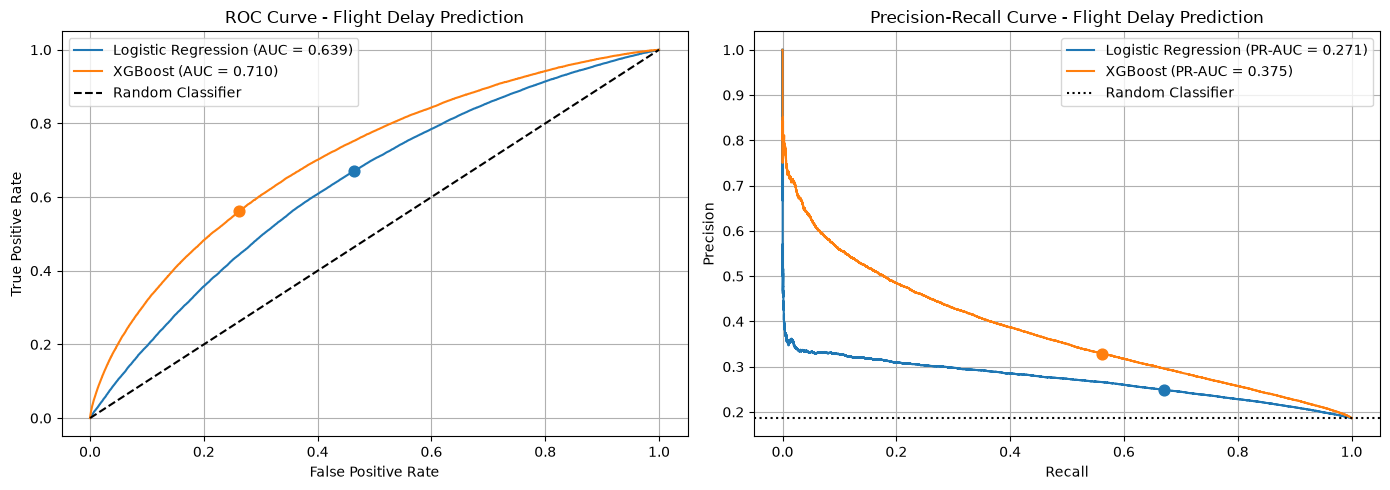

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 5))

for name, test_probs in plot_data.items():
    thr = thresholds[name]

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, test_probs)
    roc_auc = results_df.loc[results_df['Model'] == name, 'ROC-AUC'].values[0]
    line, = ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

    # PR Curve
    precision, recall, _ = precision_recall_curve(y_test, test_probs)
    pr_auc = results_df.loc[results_df['Model'] == name, 'PR-AUC'].values[0]
    ax_pr.plot(recall, precision, color=line.get_color(),
               label=f'{name} (PR-AUC = {pr_auc:.3f})')

    # Mark the chosen operating point (threshold) on both curves
    preds = (test_probs >= thr).astype(int)
    tp = ((preds == 1) & (y_test == 1)).sum()
    fp = ((preds == 1) & (y_test == 0)).sum()
    op_tpr = tp / (y_test == 1).sum()
    op_fpr = fp / (y_test == 0).sum()
    op_prec = tp / max(tp + fp, 1)
    ax_roc.scatter(op_fpr, op_tpr, color=line.get_color(), marker='o', s=60, zorder=5)
    ax_pr.scatter(op_tpr, op_prec, color=line.get_color(), marker='o', s=60, zorder=5)

# ROC Plot Styling
ax_roc.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax_roc.set_title('ROC Curve - Flight Delay Prediction')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend()
ax_roc.grid(True)

# PR Plot Styling (dotted line = delay rate, the random-model baseline)
ax_pr.axhline(y_test.mean(), color='k', linestyle=':', label='Random Classifier')
ax_pr.set_title('Precision-Recall Curve - Flight Delay Prediction')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend()
ax_pr.grid(True)

plt.tight_layout()
plt.show()